In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
from tensorflow.keras.layers import Dropout
import matplotlib.pyplot as plt

In [22]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [23]:
x_train.shape

(50000, 32, 32, 3)

In [24]:
x_test.shape

(10000, 32, 32, 3)

In [25]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [26]:
def plot_sample(X, y, index):
    flat = y[index][0]
    fl= f'{classes[flat]}'
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(fl)

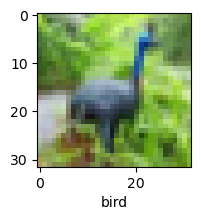

In [27]:
plot_sample(x_train, y_train, 6)

In [28]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [29]:
y_train=y_train.reshape(-1,)

In [30]:
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [31]:
classes[9]

'truck'

In [32]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [33]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [34]:
x_test[0]

array([[[0.61960784, 0.43921569, 0.19215686],
        [0.62352941, 0.43529412, 0.18431373],
        [0.64705882, 0.45490196, 0.2       ],
        ...,
        [0.5372549 , 0.37254902, 0.14117647],
        [0.49411765, 0.35686275, 0.14117647],
        [0.45490196, 0.33333333, 0.12941176]],

       [[0.59607843, 0.43921569, 0.2       ],
        [0.59215686, 0.43137255, 0.15686275],
        [0.62352941, 0.44705882, 0.17647059],
        ...,
        [0.53333333, 0.37254902, 0.12156863],
        [0.49019608, 0.35686275, 0.1254902 ],
        [0.46666667, 0.34509804, 0.13333333]],

       [[0.59215686, 0.43137255, 0.18431373],
        [0.59215686, 0.42745098, 0.12941176],
        [0.61960784, 0.43529412, 0.14117647],
        ...,
        [0.54509804, 0.38431373, 0.13333333],
        [0.50980392, 0.37254902, 0.13333333],
        [0.47058824, 0.34901961, 0.12941176]],

       ...,

       [[0.26666667, 0.48627451, 0.69411765],
        [0.16470588, 0.39215686, 0.58039216],
        [0.12156863, 0

In [35]:
ann= models.Sequential([
    layers.RandomRotation(0.1),
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    Dropout(0.5),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

c:\Users\Fiza Mumtaz Dahani\miniconda3\envs\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
ann.compile(optimizer='SGD',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
ann.fit(x_train, y_train, epochs=5)

Epoch 1/5
 445/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 48ms/step - accuracy: 0.2499 - loss: 2.0707

In [ ]:
ann.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4590 - loss: 1.5060


[1.5059775114059448, 0.45899999141693115]

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\Fiza Mumtaz Dahani\miniconda3\envs\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = cnn_model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4182 - loss: 1.5928 - val_accuracy: 0.5244 - val_loss: 1.3304
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.5599 - loss: 1.2371 - val_accuracy: 0.5944 - val_loss: 1.1572
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6139 - loss: 1.0937 - val_accuracy: 0.6285 - val_loss: 1.0593
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6481 - loss: 1.0002 - val_accuracy: 0.6446 - val_loss: 1.0238
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6754 - loss: 0.9250 - val_accuracy: 0.6594 - val_loss: 0.9725
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6970 - loss: 0.8634 - val_accuracy: 0.6752 - val_loss: 0.9363
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7195 - loss: 0.8017 - val_accuracy: 0.6783 - val_loss: 0.9304
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7362 -

In [ ]:
cnn_model.evaluate(x_test, y_test.reshape(-1,))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6880 - loss: 0.9317


[0.9316930770874023, 0.6880000233650208]

In [ ]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

In [ ]:
y_test=y_test.reshape(-1,)

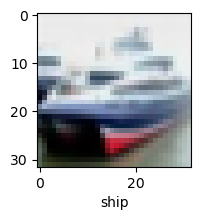

In [ ]:
plot_sample(x_test, y_test, 1)

In [ ]:
y_predicted = cnn_model.predict(x_test)
y_predicted[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[4.0818052e-03, 5.3825035e-05, 1.0902688e-02, 4.4884241e-01,
        1.8280678e-03, 4.6512264e-01, 4.8937321e-02, 4.0782761e-04,
        1.9419337e-02, 4.0402706e-04],
       [7.0004493e-02, 6.0882562e-01, 3.5591802e-06, 6.5995994e-07,
        5.9037086e-07, 2.1302275e-09, 1.4135146e-07, 4.1298428e-08,
        3.1873316e-01, 2.4317410e-03],
       [2.9947542e-02, 1.9079430e-02, 3.9981835e-04, 3.1393330e-04,
        3.2747668e-04, 2.5923984e-05, 1.7668324e-05, 8.1209320e-04,
        9.3600219e-01, 1.3073850e-02],
       [8.8931078e-01, 2.9072769e-02, 4.2451167e-04, 2.5356631e-04,
        1.3721687e-02, 9.8995852e-06, 2.0097494e-05, 8.7670298e-05,
        6.6872306e-02, 2.2663649e-04],
       [5.3582198e-07, 3.4114325e-06, 5.5474611e-03, 1.7994588e-02,
        8.9827919e-01, 5.6293043e-03, 7.2513483e-02, 2.5805484e-05,
        5.7259358e-06, 5.2762749e-07]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_predicted]
y_classes = np.array([np.argmax(element) for element in y_predicted])

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)